In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn import model_selection
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier, BaggingClassifier, GradientBoostingClassifier, VotingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score


In [2]:
df = pd.read_csv('C:/Users/71477/OneDrive - PT. Federal International Finance/External Class Training/Data Analytics/SuperStore_Orders.csv/SuperStore_Orders.csv',encoding='latin1')
df.head()

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Office Supplies,Storage,"Tenex Lockers, Blue",408,2,0.0,106.140,35.46,Medium,2011
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Office Supplies,Supplies,"Acme Trimmer, High Speed",120,3,0.1,36.036,9.72,Medium,2011
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Office Supplies,Storage,"Tenex Box, Single Width",66,4,0.0,29.640,8.17,High,2011
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Office Supplies,Paper,"Enermax Note Cards, Premium",45,3,0.5,-26.055,4.82,High,2011
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furniture,Furnishings,"Eldon Light Bulb, Duo Pack",114,5,0.1,37.770,4.70,Medium,2011


In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   order_id        51290 non-null  object 
 1   order_date      51290 non-null  object 
 2   ship_date       51290 non-null  object 
 3   ship_mode       51290 non-null  object 
 4   customer_name   51290 non-null  object 
 5   segment         51290 non-null  object 
 6   state           51290 non-null  object 
 7   country         51290 non-null  object 
 8   market          51290 non-null  object 
 9   region          51290 non-null  object 
 10  product_id      51290 non-null  object 
 11  category        51290 non-null  object 
 12  sub_category    51290 non-null  object 
 13  product_name    51290 non-null  object 
 14  sales           51290 non-null  object 
 15  quantity        51290 non-null  int64  
 16  discount        51290 non-null  float64
 17  profit          51290 non-null 

In [3]:
# Konversi kolom numerik ke tipe float
df['sales'] = pd.to_numeric(df['sales'], errors='coerce')
df['profit'] = pd.to_numeric(df['profit'], errors='coerce')
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')
df['shipping_cost'] = pd.to_numeric(df['shipping_cost'], errors='coerce')

In [130]:
df['product_name'].unique()

array(['Tenex Lockers, Blue', 'Acme Trimmer, High Speed',
       'Tenex Box, Single Width', ...,
       'Panasonic Business\xa0Telephones\xa0KX-T7736',
       'Bush Saratoga Collection 5-Shelf Bookcase, Hanover Cherry, *Special Order',
       'Acco Glide Clips'], shape=(3788,), dtype=object)

# Prediksi Profit

In [4]:
df['profit'].unique()

array([106.14  ,  36.036 ,  29.64  , ..., -37.266 ,   6.475 ,  -0.6048],
      shape=(24575,))

In [4]:
import pandas as pd

# Mean
mean_profit = df['profit'].mean()

# Median
median_profit = df['profit'].median()

# Modus (bisa lebih dari 1)
mode_profit = df['profit'].mode().tolist()

# Tampilkan hasil
print("=== Statistik Profit ===")
print(f"Mean   : {mean_profit:.2f}")
print(f"Median : {median_profit:.2f}")
print(f"Modus  : {mode_profit}")


=== Statistik Profit ===
Mean   : 28.64
Median : 9.24
Modus  : [0.0]


In [12]:
def bin_profit(p):
    if p < 0:
        return 'Rugi'
    elif p <= 30:
        return 'Untung Kecil'
    else:
        return 'Untung Besar'

df['profit_bin'] = df['profit'].apply(bin_profit)
print(df['profit_bin'].value_counts())

profit_bin
Untung Kecil    24156
Untung Besar    14591
Rugi            12543
Name: count, dtype: int64


In [13]:
df['discount'] = pd.to_numeric(df['discount'], errors='coerce')

# Binning manual: pastikan max discount tidak sama dengan 0.3
max_val = df['discount'].max()
if max_val <= 0.3:
    max_val = 1.0  # default nilai maksimal bin terakhir

df['discount_bin'] = pd.cut(
    df['discount'],
    bins=[-0.01, 0.0, 0.1, 0.3, max_val],
    labels=[0, 1, 2, 3]
)

print(df[['discount', 'discount_bin']].head())
print(df['discount_bin'].value_counts(dropna=False))

   discount discount_bin
0       0.0            0
1       0.1            1
2       0.0            0
3       0.5            3
4       0.1            1
discount_bin
0    29009
3    10361
2     7241
1     4679
Name: count, dtype: int64


In [197]:
# Category
from scipy.stats import chi2_contingency, chi2
# Daftar kolom yang diuji
target_columns = [
    'segment',
    'region',
    'ship_mode',
    'order_priority',
    'country',
    'ship_date',
    'market',
    'category',
    'sub_category',
    'customer_name',
    'product_name',
    'discount_bin'
]

# Simpan hasil
chi_results = []

# Loop uji chi-squared
for col in target_columns:
    ct = pd.crosstab(df['profit_bin'], df[col])
    chi2_stat, p_val, dof, expected = chi2_contingency(ct)
    chi2_critical = chi2.ppf(1 - 0.05, df=dof)
    conclusion = "✅Tolak H0" if chi2_stat > chi2_critical else "Gagal Tolak H0"
    
    chi_results.append({
        'Feature': col,
        'Chi2 Hitung': round(chi2_stat, 4),
        'Chi2 Tabel': round(chi2_critical, 4),
        'p-value': round(p_val, 4),
        'Kesimpulan': conclusion
    })

# Urutkan berdasarkan Chi2 Hitung
chi_df = pd.DataFrame(chi_results)
chi_df_sorted = chi_df.sort_values(by='Chi2 Hitung', ascending=False).reset_index(drop=True)

# Tampilkan hasil
print("\n========== Hasil Uji Chi-Squared terhadap 'profit_bin' ===========")
print(chi_df_sorted.to_string(index=False))


========== Hasil Uji Chi-Squared terhadap 'profit_bin' ===========
       Feature  Chi2 Hitung  Chi2 Tabel  p-value     Kesimpulan
  discount_bin   36065.6884     12.5916   0.0000      ✅Tolak H0
  product_name   28422.4752   7777.5746   0.0000      ✅Tolak H0
       country   24149.4983    332.8538   0.0000      ✅Tolak H0
  sub_category   10604.9665     46.1943   0.0000      ✅Tolak H0
      category    6220.4128      9.4877   0.0000      ✅Tolak H0
     ship_date    4812.2120   3052.9553   0.0000      ✅Tolak H0
        region    3323.9449     36.4150   0.0000      ✅Tolak H0
 customer_name    2643.4157   1681.8204   0.0000      ✅Tolak H0
        market    1397.6546     21.0261   0.0000      ✅Tolak H0
order_priority       4.2271     12.5916   0.6460 Gagal Tolak H0
     ship_mode       3.1470     12.5916   0.7902 Gagal Tolak H0
       segment       1.0461      9.4877   0.9027 Gagal Tolak H0


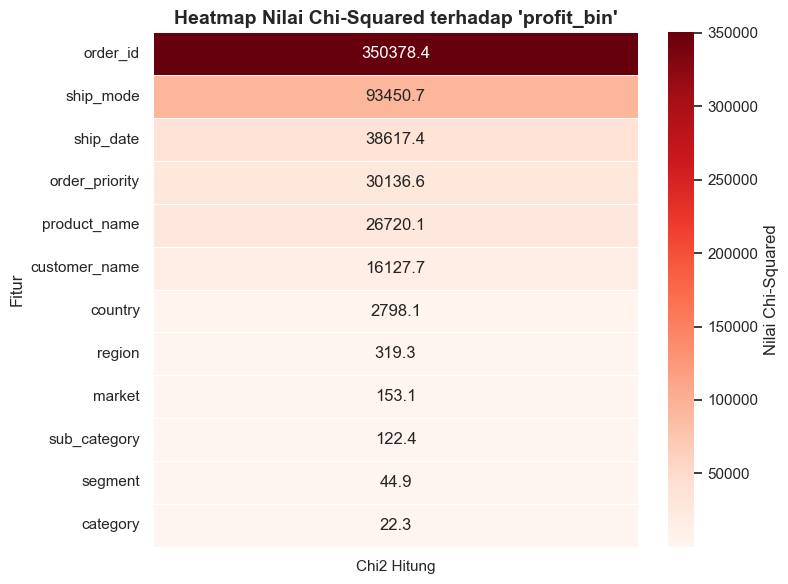

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

# Gunakan DataFrame hasil sebelumnya
chi_df_sorted = chi_df.sort_values(by='Chi2 Hitung', ascending=False).reset_index(drop=True)

# Siapkan data untuk heatmap
heatmap_data = chi_df_sorted.set_index('Feature')[['Chi2 Hitung']]

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data,
    annot=True,
    cmap='Reds',
    fmt=".1f",
    linewidths=0.5,
    cbar_kws={'label': 'Nilai Chi-Squared'}
)

# Styling
plt.title("Heatmap Nilai Chi-Squared terhadap 'profit_bin'", fontsize=14, weight='bold')
plt.xlabel("")  # tidak perlu label x
plt.ylabel("Fitur")
plt.tight_layout()

# Tampilkan
plt.show()


### XGBoost

In [100]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Pastikan target-nya tersedia
target_col = 'profit_bin'
features = [ 
    'region',
    'country',
    'ship_date',
    'market',
    'category',
    'sub_category',
    'customer_name',
    'product_name',
    'discount',
    'quantity',
    'sales', 
    'shipping_cost'
]

# Ambil fitur + target
df_subset = df[features + [target_col]].copy()

# Label Encoding untuk semua kolom object (X)
le_dict = {}
for col in features:
    if df_subset[col].dtype == 'object' or df_subset[col].dtype.name == 'category':
        le = LabelEncoder()
        df_subset[col] = le.fit_transform(df_subset[col])
        le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_subset[target_col] = le_target.fit_transform(df_subset[target_col])

# Train-test split
X = df_subset[features]
y = df_subset[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # bisa juga: median, most_frequent, constant
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [60]:
# Inisialisasi model
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss', # multiclass
    random_state=42
)

# Fit model
xgb_model.fit(X_train, y_train)

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:28:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


=== Confusion Matrix ===
[[2109  175  225]
 [  88 2423  407]
 [ 219  587 4025]]


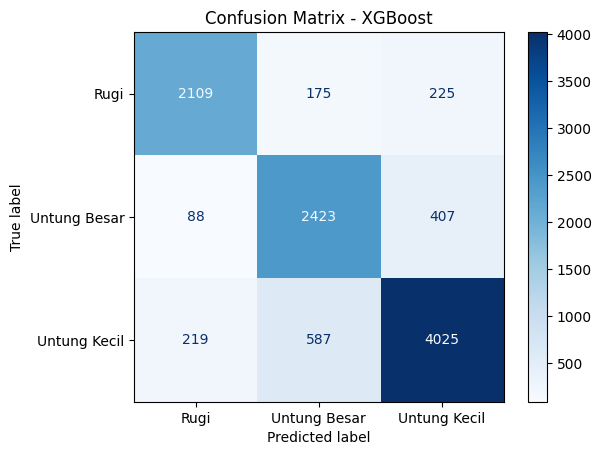


=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.87      0.84      0.86      2509
Untung Besar       0.76      0.83      0.79      2918
Untung Kecil       0.86      0.83      0.85      4831

    accuracy                           0.83     10258
   macro avg       0.83      0.83      0.83     10258
weighted avg       0.84      0.83      0.83     10258



In [61]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = xgb_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))



=== Feature Importance XGBoost ===
          Feature  XGB Importance
0        discount        0.634972
1           sales        0.188842
2        category        0.028528
3          market        0.028057
4    sub_category        0.027657
5   shipping_cost        0.017123
6    product_name        0.014831
7         country        0.014250
8          region        0.012152
9        quantity        0.011635
10      ship_date        0.011027
11  customer_name        0.010927


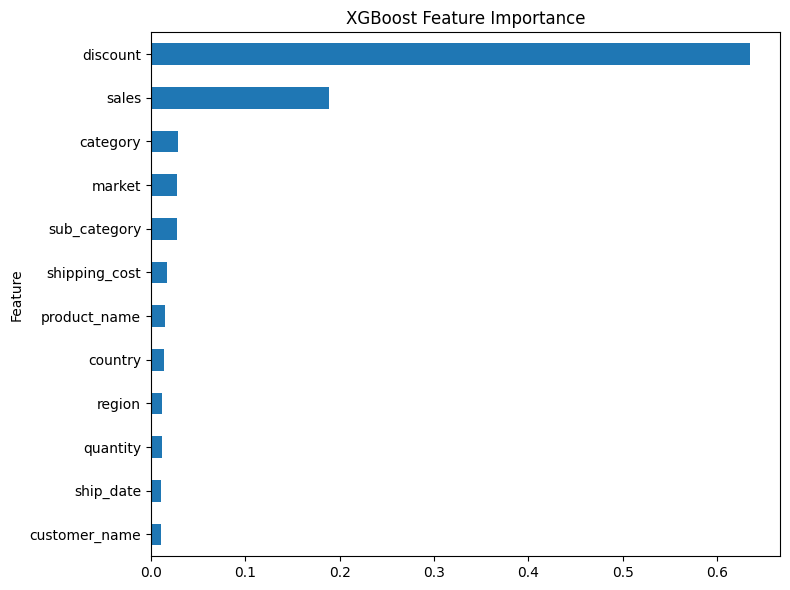

In [62]:
# Ambil feature importance
importances = xgb_model.feature_importances_
feature_names = X.columns

# Buat DataFrame
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'XGB Importance': importances
}).sort_values(by='XGB Importance', ascending=False).reset_index(drop=True)

print("\n=== Feature Importance XGBoost ===")
print(xgb_importance_df)

# Optional: Bar plot
xgb_importance_df.plot(
    kind='barh', x='Feature', y='XGB Importance', 
    figsize=(8, 6), legend=False
)
plt.title("XGBoost Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


In [46]:
# Hasil Chi-Squared dari kamu
chi_data = {
    'Feature': ['order_id', 'product_name', 'country', 'sub_category', 'category', 
                'ship_date', 'region', 'customer_name', 'market'],
    'Chi2 Hitung': [65867.9193, 28422.4752, 24149.4983, 10604.9665, 6220.4128, 
                    4812.2120, 3323.9449, 2643.4157, 1397.6546]
}

chi_df = pd.DataFrame(chi_data)

# Merge dengan XGBoost importance
combined_df = chi_df.merge(xgb_importance_df, on='Feature')
combined_df = combined_df.sort_values(by='XGB Importance', ascending=False)

print("\n=== Gabungan Chi-Squared dan XGBoost Importance ===")
print(combined_df)



=== Gabungan Chi-Squared dan XGBoost Importance ===
         Feature  Chi2 Hitung  XGB Importance
7         market    1397.6546        0.031988
3       category    6220.4128        0.028532
2   sub_category   10604.9665        0.028031
0   product_name   28422.4752        0.016059
1        country   24149.4983        0.015526
5         region    3323.9449        0.014343
4      ship_date    4812.2120        0.011935
6  customer_name    2643.4157        0.011847


In [63]:
from sklearn.metrics import roc_auc_score

# Prediksi probabilitas
y_proba = xgb_model.predict_proba(X_test)

# Hitung AUC multiclass
auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"\n=== ROC AUC Score (OvR) ===\n{auc_score:.4f}")



=== ROC AUC Score (OvR) ===
0.9562


# XGBoost 5 Feature

In [74]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Pastikan target-nya tersedia
target_col = 'profit_bin'
features_max = [ 
    'region',
    'country',
    'market',
    'category',
    'sub_category',
    'product_name',
    'discount',
    'sales', 
    'shipping_cost'
]

# Ambil fitur + target
df_subset = df[features_max + [target_col]].copy()

# Label Encoding untuk semua kolom object (X)
le_dict = {}
for col in features_max:
    if df_subset[col].dtype == 'object' or df_subset[col].dtype.name == 'category':
        le = LabelEncoder()
        df_subset[col] = le.fit_transform(df_subset[col])
        le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_subset[target_col] = le_target.fit_transform(df_subset[target_col])

# Train-test split
X = df_subset[features_max]
y = df_subset[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # bisa juga: median, most_frequent, constant
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [75]:
# Inisialisasi model
xgb_model = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss', # multiclass
    random_state=42
)

# Fit model
xgb_model.fit(X_train, y_train)

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [09:39:15] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


=== Confusion Matrix ===
[[2126  172  211]
 [  87 2433  398]
 [ 211  586 4034]]


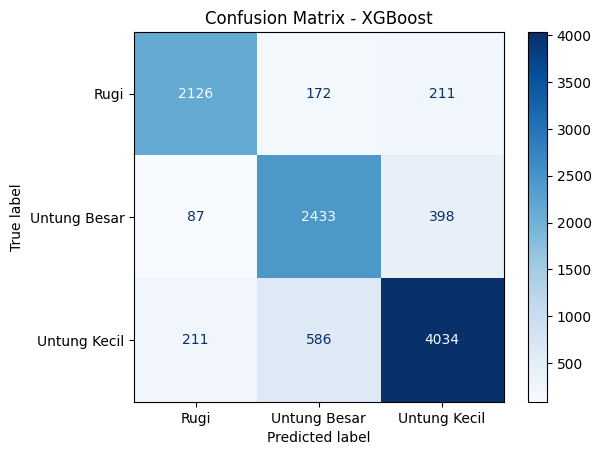


=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.88      0.85      0.86      2509
Untung Besar       0.76      0.83      0.80      2918
Untung Kecil       0.87      0.84      0.85      4831

    accuracy                           0.84     10258
   macro avg       0.84      0.84      0.84     10258
weighted avg       0.84      0.84      0.84     10258


=== Accuracy Score ===
0.837687658412946


In [76]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = xgb_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

print("\n=== Accuracy Score ===")
print(accuracy_score(y_test, y_pred))

# Random Forest 7 Features

In [182]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Pastikan target-nya tersedia
target_col = 'profit_bin'
features_max = [ 
    'discount',
    'sales', 
    'shipping_cost',
    'product_name',
    'sub_category','market'
]

# Ambil fitur + target
df_subset = df[features_max + [target_col]].copy()

# Label Encoding untuk semua kolom object (X)
le_dict = {}
for col in features_max:
    if df_subset[col].dtype == 'object' or df_subset[col].dtype.name == 'category':
        le = LabelEncoder()
        df_subset[col] = le.fit_transform(df_subset[col])
        le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_subset[target_col] = le_target.fit_transform(df_subset[target_col])

# Train-test split
X = df_subset[features_max]
y = df_subset[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')  # bisa juga: median, most_frequent, constant
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

In [183]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # jumlah pohon
    max_depth=None,        # kedalaman pohon (None = sampai sempurna)
    random_state=42
)

# Fit model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Accuracy Score ===")
print(accuracy_score(y_test, y_pred))


=== Confusion Matrix ===
[[2136  167  206]
 [  99 2458  361]
 [ 199  531 4101]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.85      0.86      2509
           1       0.78      0.84      0.81      2918
           2       0.88      0.85      0.86      4831

    accuracy                           0.85     10258
   macro avg       0.84      0.85      0.85     10258
weighted avg       0.85      0.85      0.85     10258


=== Accuracy Score ===
0.8476311171768376



=== Confusion Matrix ===
[[2136  167  206]
 [  99 2458  361]
 [ 199  531 4101]]


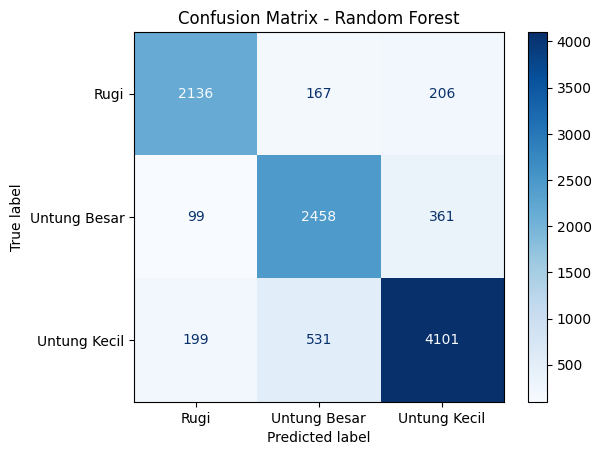


=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.88      0.85      0.86      2509
Untung Besar       0.78      0.84      0.81      2918
Untung Kecil       0.88      0.85      0.86      4831

    accuracy                           0.85     10258
   macro avg       0.84      0.85      0.85     10258
weighted avg       0.85      0.85      0.85     10258



In [184]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = rf_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))



=== Feature Importance ===
         Feature  RF Importance
0       discount       0.351595
1          sales       0.272951
2  shipping_cost       0.184113
3   product_name       0.115046
4   sub_category       0.045771
5         market       0.030524


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

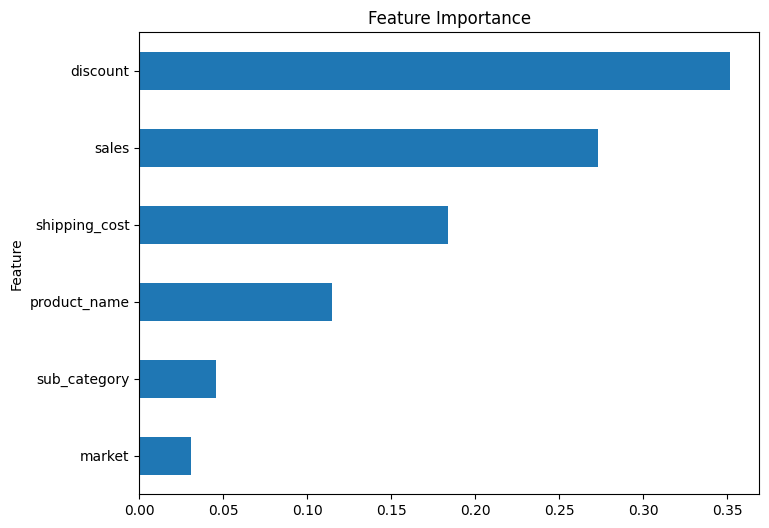

In [186]:
# Ambil feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Buat DataFrame
xgb_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': importances
}).sort_values(by='RF Importance', ascending=False).reset_index(drop=True)

print("\n=== Feature Importance ===")
print(xgb_importance_df)

# Optional: Bar plot
xgb_importance_df.plot(
    kind='barh', x='Feature', y='RF Importance', 
    figsize=(8, 6), legend=False
)
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout

In [98]:
from sklearn.metrics import roc_auc_score

# Prediksi probabilitas
y_proba = rf_model.predict_proba(X_test)

# Hitung AUC multiclass
auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"\n=== ROC AUC Score (OvR) ===\n{auc_score:.4f}")


=== ROC AUC Score (OvR) ===
0.9616


# Random Forest

In [101]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Inisialisasi model Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,      # jumlah pohon
    max_depth=None,        # kedalaman pohon (None = sampai sempurna)
    random_state=42
)

# Fit model
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi
print("=== Confusion Matrix ===")
print(confusion_matrix(y_test, y_pred))

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

print("\n=== Accuracy Score ===")
print(accuracy_score(y_test, y_pred))


=== Confusion Matrix ===
[[2110  177  222]
 [  84 2436  398]
 [ 214  583 4034]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      2509
           1       0.76      0.83      0.80      2918
           2       0.87      0.84      0.85      4831

    accuracy                           0.84     10258
   macro avg       0.84      0.84      0.84     10258
weighted avg       0.84      0.84      0.84     10258


=== Accuracy Score ===
0.836420354844999



=== Confusion Matrix ===
[[2110  177  222]
 [  84 2436  398]
 [ 214  583 4034]]


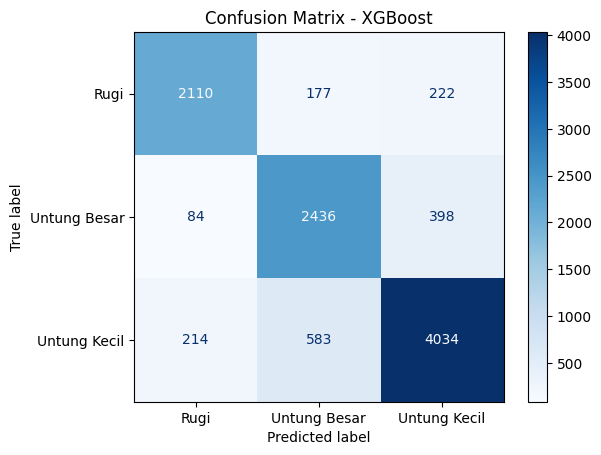


=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.88      0.84      0.86      2509
Untung Besar       0.76      0.83      0.80      2918
Untung Kecil       0.87      0.84      0.85      4831

    accuracy                           0.84     10258
   macro avg       0.84      0.84      0.84     10258
weighted avg       0.84      0.84      0.84     10258



In [66]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = rf_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))



=== Feature Importance ===
          Feature  RF Importance
0        discount       0.328408
1           sales       0.206071
2   shipping_cost       0.142816
3    product_name       0.060701
4       ship_date       0.052984
5   customer_name       0.052435
6         country       0.035881
7        quantity       0.032593
8    sub_category       0.030435
9        category       0.021333
10         region       0.020240
11         market       0.016104


<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

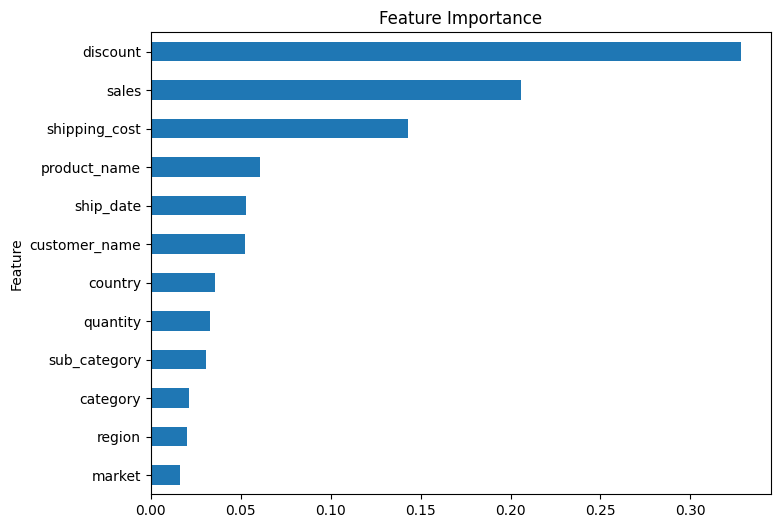

In [103]:
# Ambil feature importance
importances = rf_model.feature_importances_
feature_names = X.columns

# Buat DataFrame
rf_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'RF Importance': importances
}).sort_values(by='RF Importance', ascending=False).reset_index(drop=True)

print("\n=== Feature Importance ===")
print(xgb_importance_df)

# Optional: Bar plot
xgb_importance_df.plot(
    kind='barh', x='Feature', y='RF Importance', 
    figsize=(8, 6), legend=False
)
plt.title("Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout

# Eksplorasi Model Lain untuk Prediksi Profit Bin

In [16]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

ensemble = VotingClassifier(estimators=[
    ('xgb', XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')),
    ('rf', RandomForestClassifier()),
    ('lr', LogisticRegression(max_iter=1000))
], voting='soft')

ensemble.fit(X_train, y_train)
y_pred_ensemble = ensemble.predict(X_test)
print(classification_report(y_test, y_pred_ensemble, target_names=le_target.classes_))

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [08:18:07] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


              precision    recall  f1-score   support

        Rugi       0.84      0.87      0.86      2509
Untung Besar       0.72      0.56      0.63      2918
Untung Kecil       0.75      0.84      0.79      4831

    accuracy                           0.77     10258
   macro avg       0.77      0.76      0.76     10258
weighted avg       0.76      0.77      0.76     10258



In [17]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1],
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)
print(f"Best Params: {grid.best_params_}")
print(f"Best Score : {grid.best_score_:.4f}")

# Model terbaik
best_model = grid.best_estimator_


Fitting 3 folds for each of 72 candidates, totalling 216 fits


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:32:41] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 1}
Best Score : 0.7172


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:34:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Confusion Matrix ===
[[1739  338  432]
 [ 193 1718 1007]
 [ 263  636 3932]]

=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.79      0.69      0.74      2509
Untung Besar       0.64      0.59      0.61      2918
Untung Kecil       0.73      0.81      0.77      4831

    accuracy                           0.72     10258
   macro avg       0.72      0.70      0.71     10258
weighted avg       0.72      0.72      0.72     10258



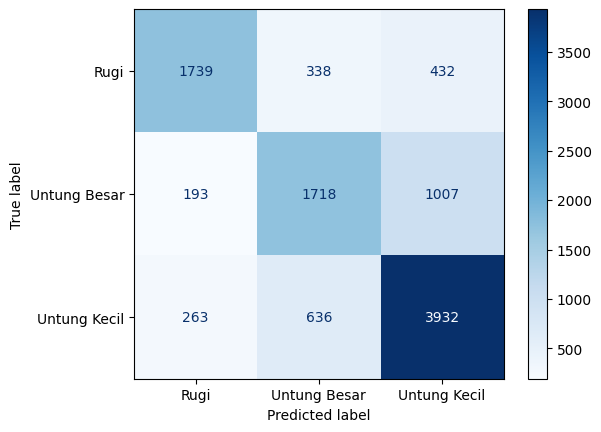

In [18]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Gunakan model terbaik
best_model = XGBClassifier(
    colsample_bytree=0.8,
    learning_rate=0.1,
    max_depth=7,
    n_estimators=200,
    subsample=1,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Latih ulang
best_model.fit(X_train, y_train)

# Prediksi
y_pred = best_model.predict(X_test)

# Evaluasi
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues')

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st

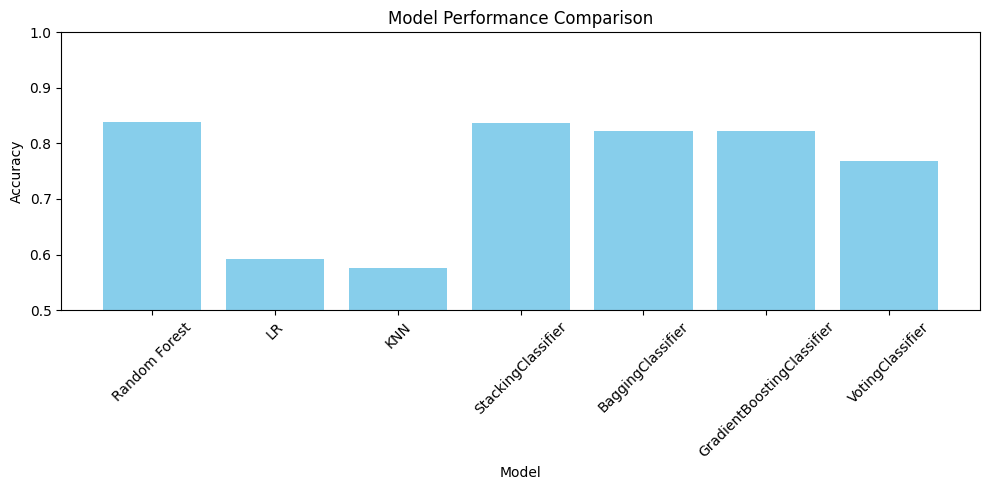

Random Forest            : 0.8391
LR                       : 0.5912
KNN                      : 0.5760
StackingClassifier       : 0.8369
BaggingClassifier        : 0.8232
GradientBoostingClassifier: 0.8232
VotingClassifier         : 0.7678


In [48]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import StackingClassifier, BaggingClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')  # bisa juga: median, most_frequent, constant
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(imputer.transform(X_test), columns=X_test.columns)

# Define base models
rf = RandomForestClassifier(n_estimators=100, random_state=42)
lr = LogisticRegression()
knn = KNeighborsClassifier(n_neighbors=5)

XGBoostClassifiers = ['StackingClassifier', 'BaggingClassifier', 'GradientBoostingClassifier', 'VotingClassifier']
base_models = [('rf', rf), ('lr', lr), ('knn', knn)]
dc = DecisionTreeClassifier()
xgb = XGBClassifier(n_estimators=100, learning_rate=0.01, random_state=42)

acc = []
for classifier in enumerate(XGBoostClassifiers):
    # Define, train and evaluate the ensemble models
    i,cf = classifier
    if i == 0:
        ensemble = StackingClassifier(estimators=base_models, final_estimator=xgb)
    elif i == 1:
        ensemble = BaggingClassifier(estimator=dc, n_estimators=10)
    elif i == 2:
        ensemble = GradientBoostingClassifier(learning_rate=1.0, max_depth=1, random_state=0, n_estimators=10)
    else :
        ensemble = VotingClassifier(estimators=base_models, voting='soft')

    ensemble.fit(X_train, y_train)
    y_pred = ensemble.predict(X_test)
    acc.append(accuracy_score(y_test, y_pred))

# Train and evaluate individual models
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

# Visualize the performance comparison
emodels = ['Random Forest', 'LR', 'KNN'] + XGBoostClassifiers
models = enumerate(emodels)
imodels = []
for model in enumerate(emodels):
    i, j = model 
    imodels.append(j)

accuracies = [accuracy_rf, accuracy_lr, accuracy_knn] + acc

plt.figure(figsize=(10, 5))
plt.bar(imodels, accuracies, color='skyblue')
plt.title('Model Performance Comparison')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.5, 1.0)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

for name, acc_val in zip(imodels, accuracies):
    print(f"{name:25}: {acc_val:.4f}")

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/st


=== Confusion Matrix ===
[[2165  161  183]
 [ 126 1809  983]
 [ 271  642 3918]]


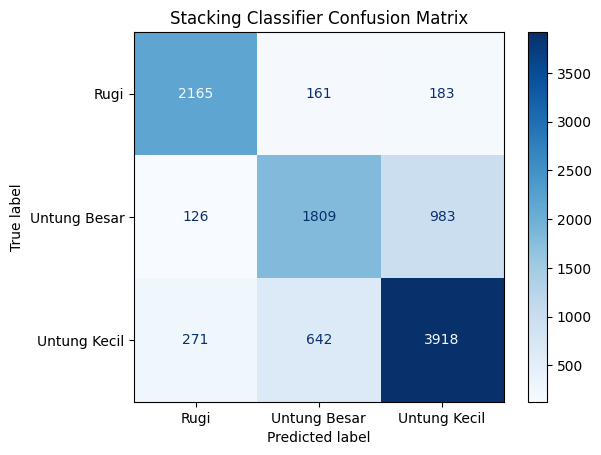


=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.85      0.86      0.85      2509
Untung Besar       0.69      0.62      0.65      2918
Untung Kecil       0.77      0.81      0.79      4831

    accuracy                           0.77     10258
   macro avg       0.77      0.76      0.77     10258
weighted avg       0.77      0.77      0.77     10258



In [18]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# Base learners
base_models = [
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42)),
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('knn', KNeighborsClassifier(n_neighbors=5))
]

# Meta learner (XGBoost)
meta_learner = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Stacking classifier
stacking_clf = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_learner,
    passthrough=True  # optional, kalau mau base model output ikut masuk ke meta model
)

# Fit model
stacking_clf.fit(X_train, y_train)

# Predict
y_pred = stacking_clf.predict(X_test)

# Evaluasi
print("\n=== Confusion Matrix ===")
cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_)
disp.plot(cmap='Blues')
plt.title("Stacking Classifier Confusion Matrix")
plt.show()

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000837 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 947
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 9
[LightGBM] [Info] Start training from score -1,408373
[LightGBM] [Info] Start training from score -1,257074
[LightGBM] [Info] Start training from score -0,752953
Accuracy: 0.7651

=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.85      0.86      0.85      2509
Untung Besar       0.70      0.59      0.64      2918
Untung Kecil       0.76      0.82      0.79      4831

    accuracy                           0.77     10258
   macro avg       0.77      0.76      0.76     10258
weighted avg       0.76      0.77      0.76     10258



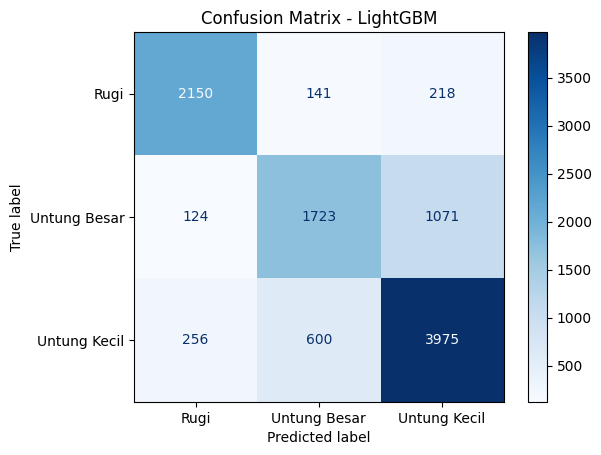

In [19]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Inisialisasi LightGBM
lgbm = LGBMClassifier(
    objective='multiclass',
    num_class=3,
    random_state=42,
    n_estimators=100,
    learning_rate=0.1
)

# Fit model
lgbm.fit(X_train, y_train)

# Prediksi
y_pred = lgbm.predict(X_test)

# Evaluasi
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(cmap='Blues')
plt.title("Confusion Matrix - LightGBM")
plt.show()


# Coba Tuning

Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fi

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [21:53:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Params: OrderedDict({'colsample_bytree': 0.9061979941786817, 'gamma': 0.8593578069828035, 'learning_rate': 0.07645185888630145, 'max_depth': 9, 'min_child_weight': 6, 'n_estimators': 138, 'subsample': 0.8779002664179407})
Best Score : 0.7184

=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.79      0.69      0.74      2509
Untung Besar       0.64      0.58      0.61      2918
Untung Kecil       0.73      0.82      0.77      4831

    accuracy                           0.72     10258
   macro avg       0.72      0.70      0.71     10258
weighted avg       0.72      0.72      0.72     10258



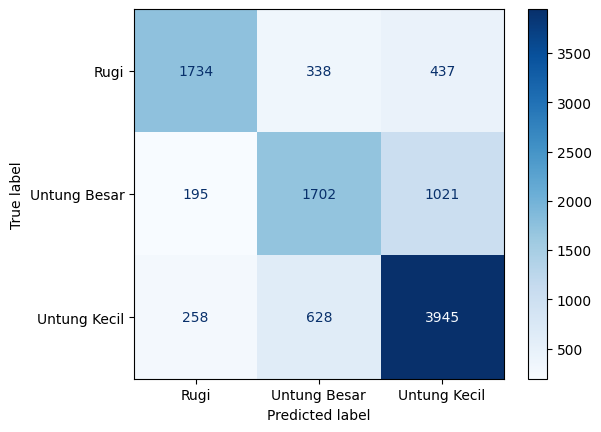

In [25]:
from skopt import BayesSearchCV
from skopt.space import Real, Integer
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score

# Inisialisasi model XGBoost
xgb = XGBClassifier(
    objective='multi:softprob',
    num_class=3,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42
)

# Ruang parameter untuk tuning
search_space = {
    'n_estimators': Integer(100, 500),
    'max_depth': Integer(3, 10),
    'learning_rate': Real(0.01, 0.3, prior='log-uniform'),
    'subsample': Real(0.5, 1.0),
    'colsample_bytree': Real(0.5, 1.0),
    'gamma': Real(0, 5),
    'min_child_weight': Integer(1, 10)
}

# K-Fold
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Bayes Search
opt = BayesSearchCV(
    estimator=xgb,
    search_spaces=search_space,
    n_iter=30,
    scoring='accuracy',
    cv=cv,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# Fit
opt.fit(X_train, y_train)

# Evaluasi
print("Best Params:", opt.best_params_)
print(f"Best Score : {opt.best_score_:.4f}")

# Gunakan model terbaik untuk prediksi
best_model = opt.best_estimator_
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=le_target.classes_).plot(cmap='Blues')


# Hyperparameter Tuning Optuna

In [26]:
%pip install optuna

   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------  2.1/2.1 MB 10.1 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 8.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [176]:
import optuna
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score
import numpy as np

# Fungsi objective untuk Optuna
def objective(trial):
    # Hyperparameter yang mau dioptimasi
    params = {
        'objective': 'multi:softprob',
        'num_class': 3,
        'eval_metric': 'mlogloss',
        'use_label_encoder': False,
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10)
    }

    # Model
    model = XGBClassifier(**params)

    # Cross-validation (3-fold)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

# Study
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

# Hasil terbaik
print("Best Parameters:")
for k, v in study.best_params.items():
    print(f"{k}: {v}")
print(f"\nBest Accuracy (CV): {study.best_value:.4f}")


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2025-06-30 11:59:48,487] A new study created in memory with name: no-name-2aa05132-e43a-4d8b-892a-29713edca0de
  0%|          | 0/30 [00:00<?, ?it/s]c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=o

[I 2025-06-30 11:59:51,641] Trial 0 finished with value: 0.8260625494561405 and parameters: {'n_estimators': 311, 'max_depth': 4, 'learning_rate': 0.06537349387717921, 'subsample': 0.7836721596581471, 'colsample_bytree': 0.5343006240686897, 'gamma': 4.854733026307876, 'min_child_weight': 8}. Best is trial 0 with value: 0.8260625494561405.


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 1. Best value: 0.828232:   7%|▋         | 2/30 [00:04<01:04,  2.32s/it]c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-06-30 11:59:53,376] Trial 1 finished with value: 0.8282315609363708 and parameters: {'n_estimators': 131, 'max_depth': 4, 'learning_rate': 0.07272160876083392, 'subsample': 0.5924910483744508, 'colsample_bytree': 0.7979767317966795, 'gamma': 1.6925869156910949, 'min_child_weight': 4}. Best is trial 1 with value: 0.8282315609363708.


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 2. Best value: 0.828329:  10%|█         | 3/30 [00:07<01:03,  2.35s/it]c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:59:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


...

[I 2025-06-30 12:01:41,242] Trial 27 finished with value: 0.8320335268813349 and parameters: {'n_estimators': 347, 'max_depth': 10, 'learning_rate': 0.15071651572555173, 'subsample': 0.6731374928179177, 'colsample_bytree': 0.6966581202544468, 'gamma': 2.5032089339804413, 'min_child_weight': 2}. Best is trial 11 with value: 0.8351530552388272.


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:42] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:43] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 11. Best value: 0.835153:  97%|█████████▋| 29/30 [01:55<00:03,  3.56s/it]c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:44] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[I 2025-06-30 12:01:44,018] Trial 28 finished with value: 0.8333008078809909 and parameters: {'n_estimators': 286, 'max_depth': 9, 'learning_rate': 0.22209353401162124, 'subsample': 0.723711138925617, 'colsample_bytree': 0.5025119294338097, 'gamma': 1.4086649801038569, 'min_child_weight': 4}. Best is trial 11 with value: 0.8351530552388272.


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:46] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
Best trial: 11. Best value: 0.835153: 100%|██████████| 30/30 [01:59<00:00,  3.99s/it]

[I 2025-06-30 12:01:48,246] Trial 29 finished with value: 0.8330327392821569 and parameters: {'n_estimators': 220, 'max_depth': 8, 'learning_rate': 0.06136817012701321, 'subsample': 0.7789530383562332, 'colsample_bytree': 0.5590455020284423, 'gamma': 0.8744458656800066, 'min_child_weight': 5}. Best is trial 11 with value: 0.8351530552388272.
Best Parameters:
n_estimators: 385
max_depth: 8
learning_rate: 0.13249222850722864
subsample: 0.8681579713887572
colsample_bytree: 0.9937577866911284
gamma: 0.6072374698360015
min_child_weight: 10

Best Accuracy (CV): 0.8352


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:01:48] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.88      0.85      0.87      2509
Untung Besar       0.77      0.84      0.81      2918
Untung Kecil       0.87      0.84      0.86      4831

    accuracy                           0.84     10258
   macro avg       0.84      0.85      0.84     10258
weighted avg       0.85      0.84      0.85     10258



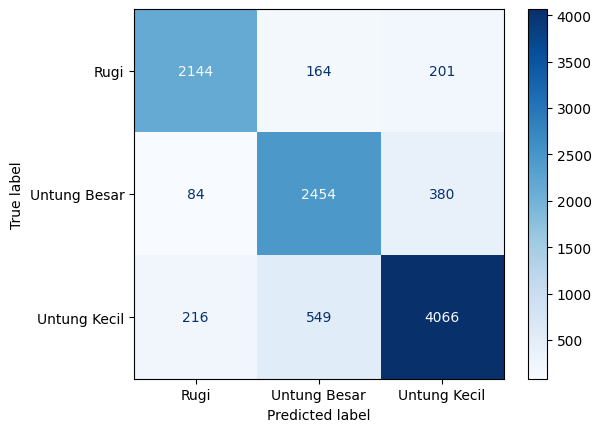

In [177]:
# Ambil model terbaik
best_params = study.best_params
best_params.update({
    'objective': 'multi:softprob',
    'num_class': 3,
    'eval_metric': 'mlogloss',
    'use_label_encoder': False
})

best_model = XGBClassifier(**best_params)
best_model.fit(X_train, y_train)

# Evaluasi di test set
y_pred = best_model.predict(X_test)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_).plot(cmap='Blues')


In [179]:
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
        'bootstrap': trial.suggest_categorical('bootstrap', [True, False]),
        'random_state': 42,
        'n_jobs': -1
    }

    model = RandomForestClassifier(**params)
    scores = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Best Params:", study.best_params)

[I 2025-06-30 12:04:14,846] A new study created in memory with name: no-name-598c34ab-ad71-438a-a6d4-041aa18076e5
[I 2025-06-30 12:04:19,489] Trial 0 finished with value: 0.8317898283171065 and parameters: {'n_estimators': 365, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 7, 'max_features': 'log2', 'bootstrap': True}. Best is trial 0 with value: 0.8317898283171065.
[I 2025-06-30 12:04:21,900] Trial 1 finished with value: 0.8326671887630752 and parameters: {'n_estimators': 159, 'max_depth': 19, 'min_samples_split': 9, 'min_samples_leaf': 5, 'max_features': 'log2', 'bootstrap': True}. Best is trial 1 with value: 0.8326671887630752.
[I 2025-06-30 12:04:27,681] Trial 2 finished with value: 0.8044208165760168 and parameters: {'n_estimators': 151, 'max_depth': 19, 'min_samples_split': 3, 'min_samples_leaf': 2, 'max_features': None, 'bootstrap': False}. Best is trial 1 with value: 0.8326671887630752.
[I 2025-06-30 12:04:29,677] Trial 3 finished with value: 0.8222119111513547 a

Best Params: {'n_estimators': 489, 'max_depth': 16, 'min_samples_split': 3, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'bootstrap': False}



=== Classification Report ===
              precision    recall  f1-score   support

        Rugi       0.88      0.84      0.86      2509
Untung Besar       0.77      0.85      0.81      2918
Untung Kecil       0.88      0.84      0.86      4831

    accuracy                           0.85     10258
   macro avg       0.84      0.84      0.84     10258
weighted avg       0.85      0.85      0.85     10258



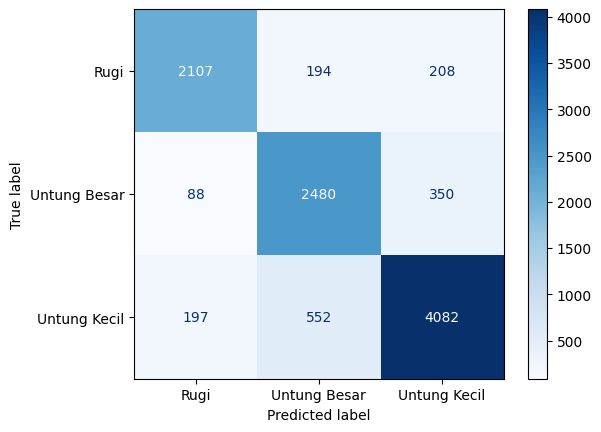

In [180]:
# Train model dengan best params
best_rf = RandomForestClassifier(**study.best_params)
best_rf.fit(X_train, y_train)

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

y_pred = best_rf.predict(X_test)

print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_target.classes_).plot(cmap='Blues')


In [181]:
print("\n=== Accuracy Score ===")
print(accuracy_score(y_test, y_pred))


=== Accuracy Score ===
0.8450965100409437


In [29]:
from sklearn.metrics import roc_auc_score

# Prediksi probabilitas
y_proba = best_model.predict_proba(X_test)

# Hitung AUC multiclass
auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"\n=== ROC AUC Score (OvR) ===\n{auc_score:.4f}")



=== ROC AUC Score (OvR) ===
0.8803


# Analisis penyebab profit

# Delivery Speed Bin

# Best Delivery Speed Bin Model

Akurasi: 0.8066874634431663

=== Classification Report ===
              precision    recall  f1-score   support

      0 hari       0.98      1.00      0.99       520
      1 hari       0.82      0.72      0.77       333
      2 hari       0.83      0.85      0.84      1405
      3 hari       0.78      0.79      0.79      1007
      4 hari       0.83      0.83      0.83      2887
      5 hari       0.78      0.79      0.78      2244
      6 hari       0.76      0.75      0.75      1251
      7 hari       0.76      0.73      0.75       611

    accuracy                           0.81     10258
   macro avg       0.82      0.81      0.81     10258
weighted avg       0.81      0.81      0.81     10258



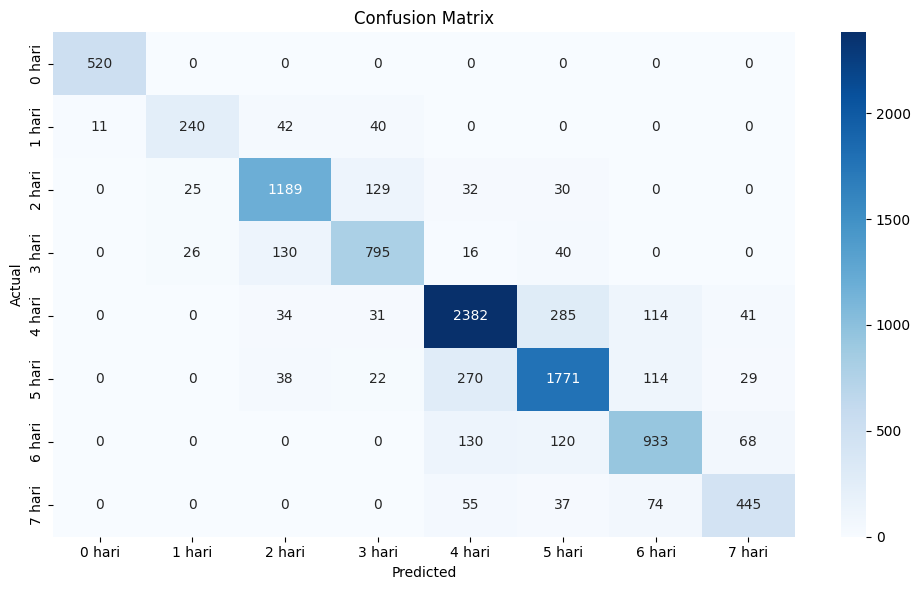

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Pastikan kolom target dan fitur sudah sesuai
target_col = 'delivery_days_cat'
features = [ 
    'region', 'country', 'ship_mode', 'order_priority', 
    'state', 'market', 'segment', 'customer_name'
]

# Copy data
df_rf = df_model[features + [target_col]].copy()

# Encode fitur kategorikal
le_dict = {}
for col in features:
    if df_rf[col].dtype == 'object' or df_rf[col].dtype.name == 'category':
        le = LabelEncoder()
        df_rf[col] = le.fit_transform(df_rf[col])
        le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_rf[target_col] = le_target.fit_transform(df_rf[target_col])

# Split data
X = df_rf[features]
y = df_rf[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

# Inisialisasi dan fit Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Prediksi
y_pred = rf_model.predict(X_test)

# Evaluasi
print("Akurasi:", accuracy_score(y_test, y_pred))
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

# Confusion matrix
plt.figure(figsize=(10, 6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import roc_auc_score

# Prediksi probabilitas
y_proba = rf_model.predict_proba(X_test)

# Hitung AUC multiclass
auc_score = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"\n=== ROC AUC Score (OvR) ===\n{auc_score:.4f}")


=== ROC AUC Score (OvR) ===
0.9665


C:\Users\71477\AppData\Local\Temp\ipykernel_13748\1592294980.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


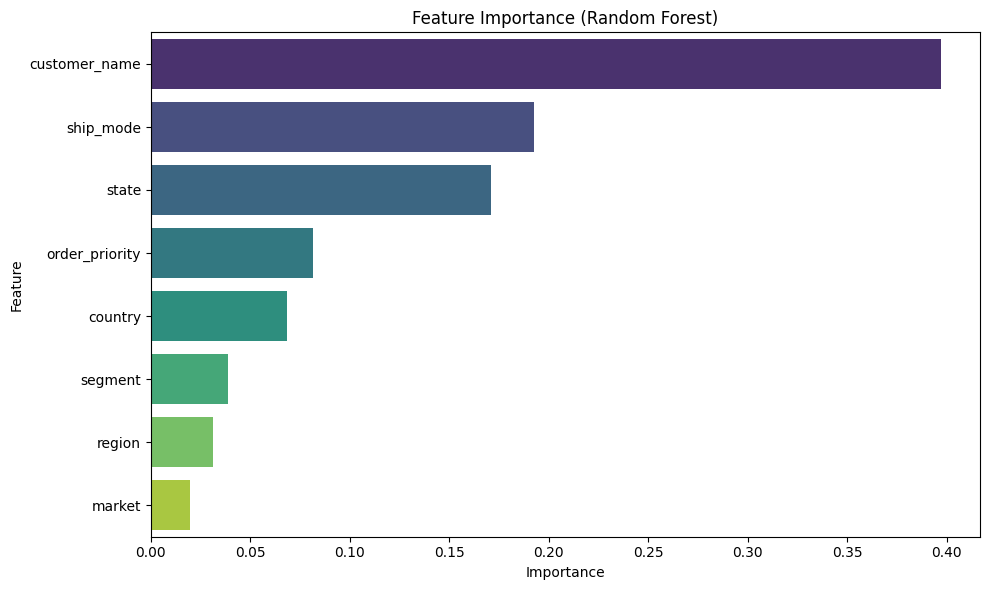

In [ ]:
# --- Feature Importance ---
importances = rf_model.feature_importances_
feature_names = X.columns

# Buat DataFrame untuk plot
fi_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [ ]:
df.head(10)

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_bin
0,AG-2011-2040,01-01-2011,06-01-2011,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,Storage,"Tenex Lockers, Blue",408.0,2,0.0,106.140,35.46,Medium,2011,Untung Besar
1,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Supplies,"Acme Trimmer, High Speed",120.0,3,0.1,36.036,9.72,Medium,2011,Untung Besar
2,HU-2011-1220,01-01-2011,05-01-2011,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,Storage,"Tenex Box, Single Width",66.0,4,0.0,29.640,8.17,High,2011,Untung Kecil
3,IT-2011-3647632,01-01-2011,05-01-2011,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,Paper,"Enermax Note Cards, Premium",45.0,3,0.5,-26.055,4.82,High,2011,Rugi
4,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Furnishings,"Eldon Light Bulb, Duo Pack",114.0,5,0.1,37.770,4.70,Medium,2011,Untung Besar
5,IN-2011-47883,01-01-2011,08-01-2011,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,Paper,"Eaton Computer Printout Paper, 8.5 x 11",55.0,2,0.1,15.342,1.80,Medium,2011,Untung Kecil
6,CA-2011-1510,02-01-2011,06-01-2011,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,...,Machines,"Okidata Inkjet, Wireless",314.0,1,0.0,3.120,24.10,Medium,2011,Untung Kecil
7,IN-2011-79397,03-01-2011,03-01-2011,Same Day,Kean Nguyen,Corporate,New South Wales,Australia,APAC,Oceania,...,Appliances,"Hoover Microwave, White",276.0,1,0.1,110.412,125.32,Critical,2011,Untung Besar
8,ID-2011-80230,03-01-2011,09-01-2011,Standard Class,Ken Lonsdale,Consumer,Auckland,New Zealand,APAC,Oceania,...,Copiers,"Hewlett Wireless Fax, Laser",912.0,4,0.4,-319.464,107.10,Low,2011,Rugi
9,IZ-2011-4680,03-01-2011,07-01-2011,Standard Class,Lindsay Williams,Corporate,Ninawa,Iraq,EMEA,EMEA,...,Chairs,"Novimex Swivel Stool, Set of Two",667.0,4,0.0,253.320,81.26,High,2011,Untung Besar


In [ ]:
print(df['order_date'].unique()[:10])
print(df['ship_date'].unique()[:10])

['01-01-2011' '02-01-2011' '03-01-2011' '04-01-2011' '05-01-2011'
 '06-01-2011' '07-01-2011' '08-01-2011' '09-01-2011' '10-01-2011']
['06-01-2011' '08-01-2011' '05-01-2011' '03-01-2011' '09-01-2011'
 '07-01-2011' '11-01-2011' '10-01-2011' '13-01-2011' '12-01-2011']


In [ ]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', dayfirst=True)
df['ship_date'] = pd.to_datetime(df['ship_date'], errors='coerce', dayfirst=True)

In [ ]:
print(df[['order_date', 'ship_date']].head())
print(df[['order_date', 'ship_date']].info())

  order_date  ship_date
0 2011-01-01 2011-01-06
1 2011-01-01 2011-01-08
2 2011-01-01 2011-01-05
3 2011-01-01 2011-01-05
4 2011-01-01 2011-01-08
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   order_date  51290 non-null  datetime64[ns]
 1   ship_date   51290 non-null  datetime64[ns]
dtypes: datetime64[ns](2)
memory usage: 801.5 KB
None


In [ ]:
# Hitung selisih hari antara pengiriman dan pemesanan
df['delivery_days'] = (df['ship_date'] - df['order_date']).dt.days

In [ ]:
df

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_bin,delivery_days,delivery_days_cat
0,AG-2011-2040,2011-01-01,2011-01-06,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,...,408.0,2,0.0,106.1400,35.46,Medium,2011,Untung Besar,5,5 hari
1,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,120.0,3,0.1,36.0360,9.72,Medium,2011,Untung Besar,7,7 hari
2,HU-2011-1220,2011-01-01,2011-01-05,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,...,66.0,4,0.0,29.6400,8.17,High,2011,Untung Kecil,4,4 hari
3,IT-2011-3647632,2011-01-01,2011-01-05,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,...,45.0,3,0.5,-26.0550,4.82,High,2011,Rugi,4,4 hari
4,IN-2011-47883,2011-01-01,2011-01-08,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,...,114.0,5,0.1,37.7700,4.70,Medium,2011,Untung Besar,7,7 hari
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51285,CA-2014-115427,2014-12-31,2015-01-04,Standard Class,Erica Bern,Corporate,California,United States,US,West,...,14.0,2,0.2,4.5188,0.89,Medium,2014,Untung Kecil,4,4 hari
51286,MO-2014-2560,2014-12-31,2015-01-05,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,...,4.0,1,0.0,0.4200,0.49,Medium,2014,Untung Kecil,5,5 hari
51287,MX-2014-110527,2014-12-31,2015-01-02,Second Class,Charlotte Melton,Consumer,Managua,Nicaragua,LATAM,Central,...,26.0,3,0.0,12.3600,0.35,Medium,2014,Untung Kecil,2,2 hari
51288,MX-2014-114783,2014-12-31,2015-01-06,Standard Class,Tamara Dahlen,Consumer,Chihuahua,Mexico,LATAM,North,...,7.0,1,0.0,0.5600,0.20,Medium,2014,Untung Kecil,6,6 hari


In [ ]:
df['delivery_days'].unique()

array([5, 7, 4, 0, 6, 2, 3, 1])

In [ ]:
# # Bikin kategori berdasarkan delivery_days
# def categorize_delivery_speed(days):
#     if days <= 1:
#         return 'Cepat'
#     elif days <= 3:
#         return 'Sedang'
#     else:
#         return 'Lambat'

# df['delivery_speed_bin'] = df['delivery_days'].apply(categorize_delivery_speed)
### GAJADI DIBIKIN KATEGORI KARNA TERNYATA CUMA 0 1 2 3 4 5 6 7 

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   order_id        51290 non-null  int64         
 1   order_date      51290 non-null  datetime64[ns]
 2   ship_date       51290 non-null  datetime64[ns]
 3   ship_mode       51290 non-null  int64         
 4   customer_name   51290 non-null  int64         
 5   segment         51290 non-null  int64         
 6   state           51290 non-null  int64         
 7   country         51290 non-null  int64         
 8   market          51290 non-null  int64         
 9   region          51290 non-null  int64         
 10  product_id      51290 non-null  int64         
 11  category        51290 non-null  int64         
 12  sub_category    51290 non-null  int64         
 13  product_name    51290 non-null  int64         
 14  sales           48660 non-null  float64       
 15  qu

In [ ]:
# Ubah ke string kategori
df['delivery_days_cat'] = df['delivery_days'].astype(str) + ' hari'

# Pastikan tipe datanya object (kategori)
print(df['delivery_days_cat'].value_counts())

delivery_days_cat
4 hari    14434
5 hari    11221
2 hari     7026
6 hari     6255
3 hari     5035
7 hari     3057
0 hari     2600
1 hari     1662
Name: count, dtype: int64


In [ ]:
# Category
from scipy.stats import chi2_contingency, chi2
# Daftar kolom yang diuji
target_columns = [
    'segment',
    'region',
    'ship_mode',
    'order_priority',
    'country',
    'ship_date',
    'market',
    'category',
    'sub_category',
    'customer_name',
    'order_id',
    'product_name'
]

# Simpan hasil
chi_results = []

# Loop uji chi-squared
for col in target_columns:
    ct = pd.crosstab(df['delivery_days_cat'], df[col])
    chi2_stat, p_val, dof, expected = chi2_contingency(ct)
    chi2_critical = chi2.ppf(1 - 0.05, df=dof)
    conclusion = "✅Tolak H0" if chi2_stat > chi2_critical else "Gagal Tolak H0"
    
    chi_results.append({
        'Feature': col,
        'Chi2 Hitung': round(chi2_stat, 4),
        'Chi2 Tabel': round(chi2_critical, 4),
        'p-value': round(p_val, 4),
        'Kesimpulan': conclusion
    })

# Urutkan berdasarkan Chi2 Hitung
chi_df = pd.DataFrame(chi_results)
chi_df_sorted = chi_df.sort_values(by='p-value', ascending=True).reset_index(drop=True)

# Tampilkan hasil
print("\n======= Hasil Uji Chi-Squared terhadap 'Delivery Speed' =======")
print(chi_df_sorted.to_string(index=False))


======= Hasil Uji Chi-Squared terhadap 'Delivery Speed' =======
       Feature  Chi2 Hitung  Chi2 Tabel  p-value     Kesimpulan
       segment      44.9272     23.6848   0.0000      ✅Tolak H0
        region     319.3392    106.3948   0.0000      ✅Tolak H0
     ship_mode   93450.7180     32.6706   0.0000      ✅Tolak H0
order_priority   30136.6393     32.6706   0.0000      ✅Tolak H0
       country    2798.0755   1097.4844   0.0000      ✅Tolak H0
     ship_date   38617.3511  10477.5353   0.0000      ✅Tolak H0
        market     153.1353     58.1240   0.0000      ✅Tolak H0
 customer_name   16127.6794   5732.5505   0.0000      ✅Tolak H0
      order_id  350378.3895 176212.9057   0.0000      ✅Tolak H0
      category      22.2720     23.6848   0.0732 Gagal Tolak H0
  product_name   26720.1248  26888.8717   0.1795 Gagal Tolak H0
  sub_category     122.4037    137.7015   0.2361 Gagal Tolak H0


In [ ]:
df['ship_mode'].unique()

array([3, 2, 1, 0])

In [ ]:
# Perlu di drop karna classfier gabisa kalo ada date time
df_model = df.drop(columns=['order_date', 'ship_date'])

In [ ]:
# Pastikan integer, dan jadikan sebagai kelas
df['delivery_days_cat'] = df['delivery_days'].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   order_id           51290 non-null  object        
 1   order_date         51290 non-null  datetime64[ns]
 2   ship_date          51290 non-null  datetime64[ns]
 3   ship_mode          51290 non-null  object        
 4   customer_name      51290 non-null  object        
 5   segment            51290 non-null  object        
 6   state              51290 non-null  object        
 7   country            51290 non-null  object        
 8   market             51290 non-null  object        
 9   region             51290 non-null  object        
 10  product_id         51290 non-null  object        
 11  category           51290 non-null  object        
 12  sub_category       51290 non-null  object        
 13  product_name       51290 non-null  object        
 14  sales 

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Pastikan target-nya tersedia
target_col = 'delivery_days_cat'
features = [ 
    'region',
    'country',
    'ship_mode',
    'order_priority', 
    'state',
    'market',
    'customer_name',
    'category'
]

# Ambil fitur + target
df_subset = df_model[features + [target_col]].copy()

# Label Encoding untuk semua kolom object (X)
le_dict = {}
for col in features:
    if df_subset[col].dtype == 'object' or df_subset[col].dtype.name == 'category':
        le = LabelEncoder()
        df_subset[col] = le.fit_transform(df_subset[col])
        le_dict[col] = le

# Encode target
le_target = LabelEncoder()
df_subset[target_col] = le_target.fit_transform(df_subset[target_col])

# Train-test split
X = df_subset[features]
y = df_subset[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

In [ ]:
# Inisialisasi model
xgb_model_delivery = XGBClassifier(
    use_label_encoder=False,
    eval_metric='mlogloss', # multiclass
    random_state=42
)

# Fit model
xgb_model_delivery.fit(X_train, y_train)

c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:02:21] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)


=== Confusion Matrix ===
[[ 520    0    0    0    0    0    0    0]
 [  13  139  107   74    0    0    0    0]
 [   0   31 1079  167   27  101    0    0]
 [   0   24  300  556   29   98    0    0]
 [   0    0  135   23 2016  609   96    8]
 [   0    0   92   11  750 1300   80   11]
 [   0    0    0    0  341  349  503   58]
 [   0    0    0    0  151  139   98  223]]


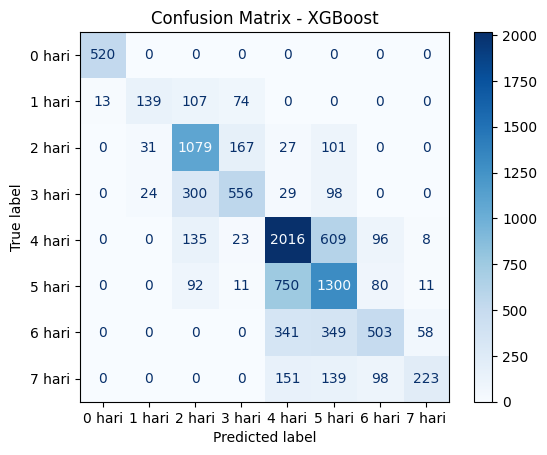


=== Classification Report ===
              precision    recall  f1-score   support

      0 hari       0.98      1.00      0.99       520
      1 hari       0.72      0.42      0.53       333
      2 hari       0.63      0.77      0.69      1405
      3 hari       0.67      0.55      0.61      1007
      4 hari       0.61      0.70      0.65      2887
      5 hari       0.50      0.58      0.54      2244
      6 hari       0.65      0.40      0.50      1251
      7 hari       0.74      0.36      0.49       611

    accuracy                           0.62     10258
   macro avg       0.69      0.60      0.62     10258
weighted avg       0.63      0.62      0.61     10258



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = xgb_model_delivery.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


In [ ]:
import pandas as pd

feat_importance = pd.DataFrame({
    'Feature': features,
    'Importance': xgb_model_delivery.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feat_importance)


          Feature  Importance
2       ship_mode    0.746325
3  order_priority    0.154964
5          market    0.017261
1         country    0.017203
4           state    0.016703
7   customer_name    0.016291
0          region    0.015784
6         segment    0.015469


In [ ]:
from sklearn.feature_selection import RFE
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Model dasar
model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)

# RFE
rfe = RFE(estimator=model, n_features_to_select=5)  # Misalnya kita ingin 5 fitur terbaik
rfe.fit(X_train, y_train)

# Lihat fitur yang dipilih
selected_rfe_features = X_train.columns[rfe.support_]
print("Fitur terpilih (RFE):", list(selected_rfe_features))

# Coba retrain model dengan fitur terpilih
X_train_rfe = X_train[selected_rfe_features]
X_test_rfe = X_test[selected_rfe_features]
model.fit(X_train_rfe, y_train)
y_pred_rfe = model.predict(X_test_rfe)

print("Accuracy with RFE:", accuracy_score(y_test, y_pred_rfe))


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:20:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:20:55] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:20:57] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:20:58] WARNING: C:\actio

Fitur terpilih (RFE): ['ship_mode', 'order_priority', 'state', 'order_id', 'customer_name']


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:21:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy with RFE: 0.6311171768375902


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:21:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


          feature  importance
2       ship_mode    0.716177
3  order_priority    0.165063
6          market    0.017750
8   customer_name    0.017609
5        order_id    0.017474
4           state    0.017119
1         country    0.017086
0          region    0.016312
7         segment    0.015409
Fitur terpilih (Importance > 0.01): ['ship_mode', 'order_priority', 'market', 'customer_name', 'order_id', 'state', 'country', 'region', 'segment']


c:\Users\71477\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:183: UserWarning: [23:21:18] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy with Feature Importance Threshold: 0.6483720023396373


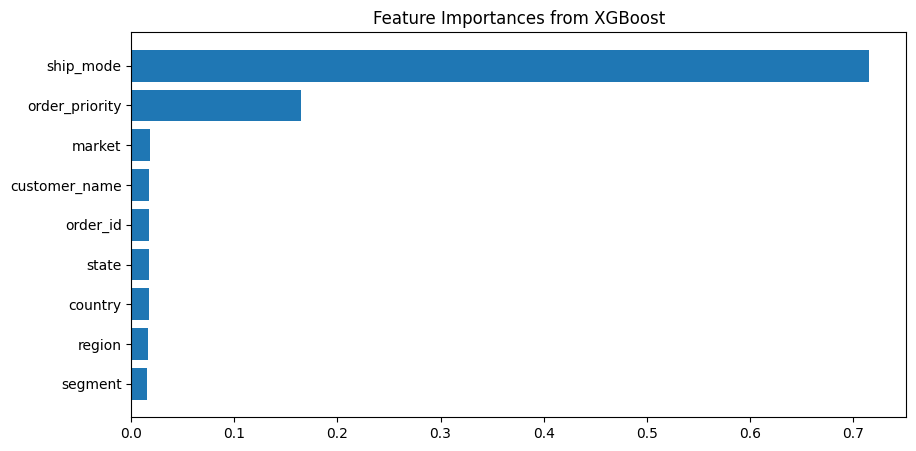

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Fit model awal
model = XGBClassifier(eval_metric='mlogloss', use_label_encoder=False, random_state=42)
model.fit(X_train, y_train)

# Ambil feature importance
importances = model.feature_importances_
importance_df = pd.DataFrame({'feature': X_train.columns, 'importance': importances})
importance_df = importance_df.sort_values('importance', ascending=False)
print(importance_df)

# Ambil fitur dengan importance di atas threshold
threshold = 0.01
selected_imp_features = importance_df[importance_df['importance'] > threshold]['feature']
print("Fitur terpilih (Importance > 0.01):", list(selected_imp_features))

# Coba retrain model
X_train_imp = X_train[selected_imp_features]
X_test_imp = X_test[selected_imp_features]
model.fit(X_train_imp, y_train)
y_pred_imp = model.predict(X_test_imp)

print("Accuracy with Feature Importance Threshold:", accuracy_score(y_test, y_pred_imp))

# (Optional) Plot
plt.figure(figsize=(10,5))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.title("Feature Importances from XGBoost")
plt.gca().invert_yaxis()
plt.show()


In [ ]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(random_state=42, n_estimators=200)
lgb_model.fit(X_train, y_train)
y_pred = lgb_model.predict(X_test)

from sklearn.metrics import accuracy_score
print("LightGBM Accuracy:", accuracy_score(y_test, y_pred))


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0,000792 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 677
[LightGBM] [Info] Number of data points in the train set: 41032, number of used features: 8
[LightGBM] [Info] Start training from score -2,981984
[LightGBM] [Info] Start training from score -3,429925
[LightGBM] [Info] Start training from score -1,987843
[LightGBM] [Info] Start training from score -2,321082
[LightGBM] [Info] Start training from score -1,267927
[LightGBM] [Info] Start training from score -1,519686
[LightGBM] [Info] Start training from score -2,104115
[LightGBM] [Info] Start training from score -2,819898
LightGBM Accuracy: 0.6607525833495809



=== Confusion Matrix ===
[[ 519    1    0    0    0    0    0    0]
 [  11  192   65   65    0    0    0    0]
 [   0   31 1148  115   26   85    0    0]
 [   0   14  238  662   25   68    0    0]
 [   0    0   84   17 2118  568   86   14]
 [   0    0   75    6  646 1428   77   12]
 [   0    0    0    0  281  302  622   46]
 [   0    0    0    0  120  118   77  296]]


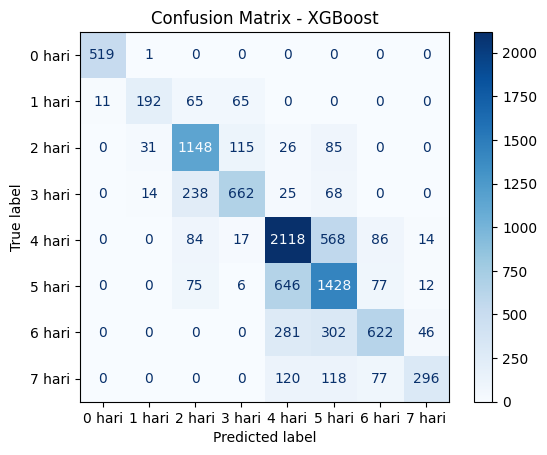


=== Classification Report ===
              precision    recall  f1-score   support

      0 hari       0.98      1.00      0.99       520
      1 hari       0.81      0.58      0.67       333
      2 hari       0.71      0.82      0.76      1405
      3 hari       0.77      0.66      0.71      1007
      4 hari       0.66      0.73      0.69      2887
      5 hari       0.56      0.64      0.59      2244
      6 hari       0.72      0.50      0.59      1251
      7 hari       0.80      0.48      0.60       611

    accuracy                           0.68     10258
   macro avg       0.75      0.68      0.70     10258
weighted avg       0.69      0.68      0.68     10258



In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Prediksi di test set
y_pred = lgb_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Visualisasi matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=le_target.classes_)  # label asli 'Untung', 'Rugi', dst.
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.show()

# Classification Report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))


# Order Priority

In [ ]:
# Category
from scipy.stats import chi2_contingency, chi2

# Fungsi lengkap dengan nilai Chi-Square hitung dan tabel
def chi_square_full(col1, col2, df, alpha=0.05):
    # Buat tabel kontingensi
    ct = pd.crosstab(df[col1], df[col2])

    # Uji Chi-Square
    chi2_stat, p_val, dof, expected = chi2_contingency(ct)
    chi2_critical = chi2.ppf(1 - alpha, df=dof)

    # Cetak hasil
    print(f"\n======= {col1} vs {col2} =======")
    print("Contingency Table:")
    print(ct)
    print(f"\nChi-Squared Hitung : {chi2_stat:.4f}")
    print(f"Chi-Squared Tabel  : {chi2_critical:.4f} (α = {alpha}, df = {dof})")
    print(f"p-value            : {p_val:.4f}")

    if chi2_stat > chi2_critical:
        print("❗ Tolak H0 → Ada hubungan signifikan antara variabel.")
    else:
        print("✅ Gagal Tolak H0 → Tidak cukup bukti ada hubungan.")

    return ct, chi2_stat, chi2_critical, p_val

# List variabel target yang ingin diuji terhadap 'category'
target_columns = [
    'segment',
    'region',
    'ship_mode',
    'country',
    'ship_date',
    'market', 'category',
    'sub_category'
]

# Looping seluruh uji
for col in target_columns:
    chi_square_full('order_priority', col, df)

# Analisis numerik: rata-rata per kategori
print("\n======= Analisis Numerik: Rata-rata per Kategori =======")
group_stats = df.groupby('order_priority')[['sales', 'profit', 'discount', 'shipping_cost']].mean()
print(group_stats)



======= order_priority vs segment =======
Contingency Table:
segment         Consumer  Corporate  Home Office
order_priority                                  
Critical            2071       1185          676
High                8257       4431         2813
Low                 1173        744          507
Medium             15017       9069         5347

Chi-Squared Hitung : 44.9504
Chi-Squared Tabel  : 12.5916 (α = 0.05, df = 6)
p-value            : 0.0000
❗ Tolak H0 → Ada hubungan signifikan antara variabel.

======= order_priority vs region =======
Contingency Table:
region          Africa  Canada  Caribbean  Central  Central Asia  EMEA  East  \
order_priority                                                                 
Critical           372      37        106      812           162   388   235   
High              1404     128        599     3172           601  1506   882   
Low                213      11         71      600            73   236   104   
Medium            2598 

In [ ]:
# Daftar kolom yang diuji
target_columns = [
    'segment',
    'region',
    'ship_mode',
    'country',
    'ship_date',
    'market',
    'category',
    'sub_category'
]

# Simpan hasil
chi_results = []

# Loop uji chi-squared
for col in target_columns:
    ct = pd.crosstab(df['order_priority'], df[col])
    chi2_stat, p_val, dof, expected = chi2_contingency(ct)
    chi2_critical = chi2.ppf(1 - 0.05, df=dof)
    conclusion = "Tolak H0" if chi2_stat > chi2_critical else "Gagal Tolak H0"
    
    chi_results.append({
        'Feature': col,
        'Chi2 Hitung': round(chi2_stat, 4),
        'Chi2 Tabel': round(chi2_critical, 4),
        'p-value': round(p_val, 4),
        'Kesimpulan': conclusion
    })

# Urutkan berdasarkan Chi2 Hitung
chi_df = pd.DataFrame(chi_results)
chi_df_sorted = chi_df.sort_values(by='Chi2 Hitung', ascending=False).reset_index(drop=True)

# Tampilkan hasil
print("\n===== Hasil Uji Chi-Squared terhadap 'order_priority' =====")
print(chi_df_sorted.to_string(index=False))


===== Hasil Uji Chi-Squared terhadap 'order_priority' =====
     Feature  Chi2 Hitung  Chi2 Tabel  p-value     Kesimpulan
   ship_date   13774.7394   4544.2366   0.0000       Tolak H0
   ship_mode   12411.0793     16.9190   0.0000       Tolak H0
     country    1305.9925    487.7935   0.0000       Tolak H0
      region     144.6263     50.9985   0.0000       Tolak H0
sub_category      49.9019     65.1708   0.3976 Gagal Tolak H0
      market      45.0264     28.8693   0.0004       Tolak H0
     segment      44.9504     12.5916   0.0000       Tolak H0
    category       6.7773     12.5916   0.3419 Gagal Tolak H0


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Encode data
df = df.dropna(subset=['order_priority'])  # pastikan target tidak ada yang kosong
label_encoders = {}
for col in df.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

# Fitur dan target
X = df.drop(columns=['order_priority'])
y = df['order_priority']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\n=== Confusion Matrix ===")
print(cm)

# Classification report
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# AUC Score (multiclass)
auc = roc_auc_score(y_test, y_proba, multi_class='ovr')
print(f"\n=== AUC Score (OvR) ===\n{auc:.4f}")



=== Confusion Matrix ===
[[ 315  417    0   54]
 [  57 1818    0 1225]
 [   0  119   19  347]
 [  18  548    0 5321]]

=== Classification Report ===
              precision    recall  f1-score   support

           0       0.81      0.40      0.54       786
           1       0.63      0.59      0.61      3100
           2       1.00      0.04      0.08       485
           3       0.77      0.90      0.83      5887

    accuracy                           0.73     10258
   macro avg       0.80      0.48      0.51     10258
weighted avg       0.74      0.73      0.70     10258


=== AUC Score (OvR) ===
0.8917


In [ ]:
# Ambil feature importance dari model Random Forest
importances = model.feature_importances_
features = X.columns

# Gabungkan jadi DataFrame dan urutkan
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# Cetak hasil
print("\n=== Feature Importance dari Random Forest ===")
print(importance_df.to_string(index=False))



=== Feature Importance dari Random Forest ===
      Feature  Importance
shipping_cost    0.132614
        sales    0.112275
    ship_mode    0.078296
   order_date    0.065938
    ship_date    0.065268
customer_name    0.063909
       profit    0.062366
     order_id    0.062025
 product_name    0.055695
   product_id    0.055194
        state    0.053769
      country    0.034366
     quantity    0.028503
 sub_category    0.026980
       region    0.025882
         year    0.020164
     discount    0.018220
       market    0.016244
      segment    0.015015
     category    0.007279


In [9]:
# Ambil index prediksi yang benar dan kelasnya 'Rugi'
rugi_label = le_target.transform(['Rugi'])[0]

# Buat DataFrame dari X_test dan hasil prediksi
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_pred

# Ambil hanya True Positive untuk kelas Rugi
true_rugi = test_results[(test_results['actual'] == rugi_label) & (test_results['predicted'] == rugi_label)]

print(f"Jumlah True Positive (Rugi): {len(true_rugi)}")

Jumlah True Positive (Rugi): 2048


In [10]:
df['profit_bin_num'] = le_target.transform(df['profit_bin'])
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns


# Hitung korelasi numerik terhadap profit_bin_num
correlations = df[numeric_cols].corrwith(df['profit_bin_num']).sort_values(key=abs, ascending=False)
print(correlations)

profit_bin_num    1.000000
discount         -0.695914
sales            -0.224645
shipping_cost    -0.149357
quantity         -0.120297
profit            0.114725
year              0.001508
dtype: float64


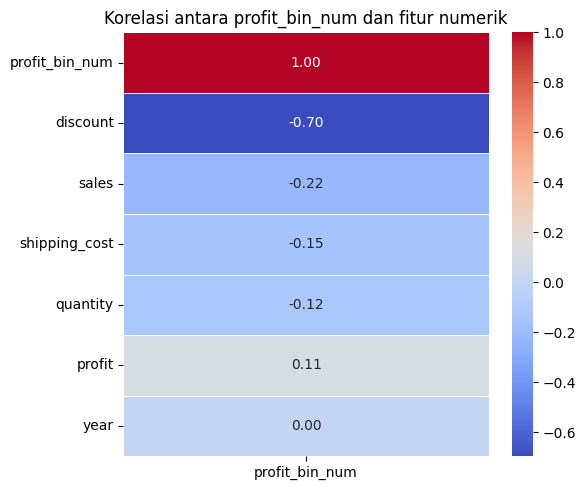

In [11]:
# Ambil korelasi antar semua kolom numerik
corr_matrix = df[numeric_cols].corr()
# Fokuskan tampilan ke baris "profit_bin_num" saja
corr_target = corr_matrix[['profit_bin_num']].sort_values(by='profit_bin_num', key=abs, ascending=False)
plt.figure(figsize=(6, 5))
sns.heatmap(corr_target, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Korelasi antara profit_bin_num dan fitur numerik")
plt.tight_layout()
plt.show()


In [126]:
rugi_label = le_target.transform(['Rugi'])[0]

# Gabungkan hasil prediksi ke data test
test_results = X_test.copy()
test_results['actual'] = y_test
test_results['predicted'] = y_pred

# Ambil indeks True Positive untuk rugi
true_rugi_idx = test_results[(test_results['actual'] == rugi_label) & (test_results['predicted'] == rugi_label)].index

# Ambil data lengkap dari df asli
true_rugi_df = df.loc[true_rugi_idx]


In [127]:
print("=== Rata-rata fitur numerik dari order yang rugi ===")
print(true_rugi_df.describe())

print("\n=== Modus fitur kategorikal ===")
print(true_rugi_df.select_dtypes(include='object').mode().iloc[0])


=== Rata-rata fitur numerik dari order yang rugi ===
            sales    quantity    discount      profit  shipping_cost  \
count  111.000000  116.000000  116.000000  116.000000     116.000000   
mean   109.711712    3.181034    0.473431  -57.344969      22.227931   
std    162.718965    2.232562    0.185866   93.943016      53.022989   
min      1.000000    1.000000    0.100000 -626.520000       0.070000   
25%     21.000000    1.000000    0.400000  -63.579000       2.077500   
50%     55.000000    3.000000    0.470000  -28.184500       6.900000   
75%    125.000000    4.000000    0.600500   -6.707250      17.282500   
max    981.000000   14.000000    0.800000   -0.015000     380.770000   

              year  
count   116.000000  
mean   2011.112069  
std       0.316820  
min    2011.000000  
25%    2011.000000  
50%    2011.000000  
75%    2011.000000  
max    2012.000000  

=== Modus fitur kategorikal ===
order_id                                 CA-2011-105984
order_date          

In [14]:
non_rugi_df = df[df['profit_bin'] != 'Rugi']

# Bandingkan diskon
print("Rata-rata diskon order rugi:", true_rugi_df['discount'].mean())
print("Rata-rata diskon order tidak rugi:", non_rugi_df['discount'].mean())


Rata-rata diskon order rugi: 0.485427734375
Rata-rata diskon order tidak rugi: 0.043225127106614705


In [ ]:
print("Jumlah fitur:", len(X.columns))
print("Jumlah importance:", len(model.feature_importances_))


Jumlah fitur: 20
Jumlah importance: 13


In [ ]:
features = model.feature_names_in_  # ← ini 100% sesuai dengan apa yang digunakan model saat training

importances = model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print(importance_df)


           Feature  Importance
0        ship_mode    0.183263
1    customer_name    0.127511
2         order_id    0.126737
3     product_name    0.098814
4       product_id    0.096294
5            state    0.094547
6   order_priority    0.077693
7          country    0.051479
8     sub_category    0.046798
9           region    0.033537
10         segment    0.031617
11          market    0.018599
12        category    0.013111


In [129]:
cross = pd.crosstab(df['discount_bin'], df['profit_bin'], normalize='index') * 100
cross = cross.round(1)

# Urutkan berdasarkan persentase 'Rugi' dari yang tertinggi
cross_sorted = cross.sort_values(by='Rugi', ascending=False)

print(cross_sorted)

profit_bin    Rugi  Untung Besar  Untung Kecil
discount_bin                                  
3             92.5           1.2           6.4
2             28.5          22.7          48.8
1             19.2          44.4          36.4
0              0.0          37.0          63.0


In [14]:
cross = pd.crosstab(df['ship_mode'], df['profit_bin'], normalize='index') * 100
cross = cross.round(1)

# Urutkan berdasarkan persentase 'Rugi' dari yang tertinggi
cross_sorted = cross.sort_values(by='Rugi', ascending=False)

print(cross_sorted)

profit_bin      Rugi  Untung Besar  Untung Kecil
ship_mode                                       
First Class     25.1          28.2          46.7
Standard Class  24.5          28.5          47.0
Second Class    24.1          28.5          47.5
Same Day        23.9          28.4          47.7


In [ ]:
cross = pd.crosstab(df['customer_name'], df['profit_bin'], normalize='index') * 100
cross = cross.round(1)

# Urutkan berdasarkan persentase 'Rugi' dari yang tertinggi
cross_sorted = cross.sort_values(by='Rugi', ascending=False)

print(cross_sorted)


profit_bin           Rugi  Untung Besar  Untung Kecil
customer_name                                        
Jill Stevenson       53.1          10.2          36.7
Bobby Trafton        52.8          11.3          35.8
Emily Burns          51.4          11.4          37.1
Catherine Glotzbach  48.6           2.9          48.6
Sharelle Roach       48.1          17.3          34.6
...                   ...           ...           ...
Annie Thurman         7.3          16.4          76.4
Bryan Spruell         7.2          26.1          66.7
Julie Prescott        6.6          21.1          72.4
Arthur Prichep        5.7          21.8          72.4
Rick Duston           3.0          33.3          63.6

[795 rows x 3 columns]


In [ ]:
cross = pd.crosstab(df['customer_name'], df['profit_bin'], normalize='index') * 100
cross = cross.round(1)

# Urutkan berdasarkan persentase 'Rugi' dari yang tertinggi
cross_sorted = cross.sort_values(by='Untung Besar', ascending=False)

print(cross_sorted)

profit_bin           Rugi  Untung Besar  Untung Kecil
customer_name                                        
Nathan Gelder        13.8          36.9          49.2
Chuck Clark          20.0          36.7          43.3
Roland Schwarz       12.2          36.7          51.0
Alan Hwang           17.6          35.1          47.3
Bradley Drucker      20.5          34.1          45.5
...                   ...           ...           ...
Pierre Wener         24.6           6.6          68.9
Nicole Brennan       45.2           6.5          48.4
David Bremer         29.4           5.9          64.7
Joni Sundaresam      41.5           5.7          52.8
Catherine Glotzbach  48.6           2.9          48.6

[795 rows x 3 columns]


In [ ]:
import numpy as np

np.unique(df['customer_name'].value_counts().values)

array([ 29,  31,  34,  35,  36,  37,  38,  39,  40,  41,  42,  43,  44,
        45,  46,  47,  48,  49,  50,  51,  52,  53,  54,  55,  56,  57,
        58,  59,  60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,
        71,  72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83,
        84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95,  96,
        97,  98, 100, 101, 102, 106, 108])

In [95]:
df[df['customer_name'] == 'Jill Stevenson']

,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,...,sales,quantity,discount,profit,shipping_cost,order_priority,year,profit_bin,delivery_days,delivery_days_cat
884,US-2011-127978,2011-03-03,2011-03-08,Standard Class,Jill Stevenson,Corporate,Ohio,United States,US,East,...,302.0,5,0.50,-199.6170,34.51,Medium,2011,Rugi,5,5
902,US-2011-127978,2011-03-03,2011-03-08,Standard Class,Jill Stevenson,Corporate,Ohio,United States,US,East,...,45.0,8,0.20,-10.0512,1.94,Medium,2011,Rugi,5,5
904,US-2011-127978,2011-03-03,2011-03-08,Standard Class,Jill Stevenson,Corporate,Ohio,United States,US,East,...,15.0,3,0.20,4.9140,1.37,Medium,2011,Untung Kecil,5,5
1539,MX-2011-101175,2011-04-11,2011-04-13,Second Class,Jill Stevenson,Corporate,San Salvador,El Salvador,LATAM,Central,...,131.0,3,0.00,46.9800,11.24,Medium,2011,Untung Besar,2,2
1540,MX-2011-101175,2011-04-11,2011-04-13,Second Class,Jill Stevenson,Corporate,San Salvador,El Salvador,LATAM,Central,...,83.0,2,0.00,21.5200,9.87,Medium,2011,Untung Kecil,2,2
4778,CA-2011-3200,2011-09-01,2011-09-04,Second Class,Jill Stevenson,Corporate,Quebec,Canada,Canada,Canada,...,138.0,1,0.00,6.8700,17.43,Medium,2011,Untung Kecil,3,3
5874,NI-2011-7770,2011-10-03,2011-10-07,Standard Class,Jill Stevenson,Corporate,Lagos,Nigeria,Africa,Africa,...,4.0,1,0.70,-9.9810,0.38,Medium,2011,Rugi,4,4
8998,ID-2012-39903,2012-01-02,2012-01-06,Standard Class,Jill Stevenson,Corporate,Sumatera Utara,Indonesia,APAC,Southeast Asia,...,NaN,6,0.17,339.8778,301.26,High,2012,Untung Besar,4,4
8999,ID-2012-39903,2012-01-02,2012-01-06,Standard Class,Jill Stevenson,Corporate,Sumatera Utara,Indonesia,APAC,Southeast Asia,...,NaN,7,0.17,399.9765,200.90,High,2012,Untung Besar,4,4
9003,ID-2012-39903,2012-01-02,2012-01-06,Standard Class,Jill Stevenson,Corporate,Sumatera Utara,Indonesia,APAC,Southeast Asia,...,627.0,9,0.27,-51.6078,61.81,High,2012,Rugi,4,4
